# Initial Info

* NOTE CALIBRATION INFO: (always adapt and save as new file, if new calibration is performed)
* Name: Mareny Fernandez
*Calibration source: Krypton lamp, persistent lines of Hg I from 570 to 880nm.
# Spectral lines taken from: https://pml.nist.gov/PhysRefData/Handbook/Tables/kryptontable2_a.htm
# Calibration date: 2026_06_04

* This calibration procedure was copied and adapted from https://github.com/ScopeFoundry/HW_acton_spec/blob/master/spectrometer_calibration.ipynb

# Calibration Procedure
* Follow the steps in this Jupyther notebook to calibrate any Princeton Instruments spectrograph.


1. Compute center offset:
 - Set $\lambda_{\rm center}$ to set of known spectral lines
 - Measure pixel position of each spectral line. The position should be roughly centered on the CCD. 
 - average each to determine central pixel $n_o$
 
|   $\lambda_{\rm center}$ | Pixel |           
| ----------------------:  |:------:|
| 0   nm                   | 508 | 
| 445 nm                   | 507     |  
| 901 nm                   | 509      | 


2. Compute spectrometer calibration angles/length ($\ f_L, \delta, \gamma$)
 * Move known spectral line $\lambda_o$ to left and right sides as well as to the center of the detector
 * record $\lambda_{\rm center}$ and pixel position for each 
 * Compute best fit of $\ f_{\rm calib}$


| $\lambda_o$   | Side | $\lambda_{\rm center}$| Pixel  |
| ------------- | ---- |:----------------------|-------:|
| 365.02 nm      | R    |265.02 nm            |905     |
| 365.02 nm      | C    |365.02 nm            |508     |
| 365.02 nm      | L    |465.02 nm            |103     |
| 404.66 nm      | R    |304.66 nm            |909     |
| ...           | ...  | ...                   |...     |

3. Check if calibration is satisfactory by plotting the residual of the fit values. Adapt initial values and data if needed.

4. SAVE notebook with corresponding name to be transparent with your colleagues! 

# Optimization Function

* This section gives a short theoretical overview of the optimization function. Just acknowledge it and continue below. 
Optimize for 3 parameters:
 * $f_L$: Focal length of spectrometer
 * $\delta$: Detector angle (The angle of the image plane relative to the plane perpendicular to the spectrograph focal axis at the center of the image plane)
 * $\gamma$: inclusion angle

from experiment:
 * $n =  n_{px} - n_o$: Pixel from central pixel
 * $\lambda_{\rm center}$: Wavelength of center pixel 
 * $\lambda_p$: Wavelength of pixel $n$
 
Fixed Constants:
 * $m$: Diffraction order (typically one)
 * $x_{\rm pixel}$: pixel size
 * $d_{grating}$: Grating pitch (1/(groves / mm))
    
residual: (wl,  wl_p, n, f, delta,gamma)

We measure pixel position ($n$) of a known wavelength ($\lambda_p$) for multple peaks and spectrometer positions and find the best fit parameters $\ f_L, \delta, \gamma$:

$$ \lambda_p = f_{\rm calib} ( n,  \lambda_{\rm center}, 
    \underbrace{m, x_{\rm pixel}, d_{\rm grating}}_{\rm spec\ params}, 
    \overbrace{f_L,\ \ \delta,\ \ \gamma}^{\rm Calibration\ params} ) $$

$$ \lambda_p = \frac{d}{m} \cdot \left[ \sin( \psi - \frac{\gamma}{2}) + \sin(\psi+\frac{\gamma}{2} + \eta) \right]$$

Where

$$ \psi = \arcsin \left[ \frac{ m\ \lambda_{\rm center} } { 2\ d_{\rm grating} \cos(\frac{\gamma}{2})} \right] $$

$$ \eta = \arctan \left[ \frac{ n\ x_{pixel} \cos{\delta}} {f_L + n\ x_{pixel} \sin(\delta)} \right]$$

$$n =  n_{px} - n_o$$



In [1]:
from __future__ import division
import numpy as np
import  matplotlib.pyplot as plt
from pprint import pprint
import numpy as np
from numba.cuda.simulator.vector_types import SimulatedVectorType

# matplotlib notebook

In [2]:
def wl_p_calib_p2(px, n0, offset_adjust, wl_center, m_order, d_grating, x_pixel, f, delta, gamma, curvature):
    #consts
    #d_grating = 1./150. #mm
    #x_pixel   = 16e-3 # mm
    #m_order   = 1 # diffraction order, unitless
    n = px - (n0+offset_adjust*wl_center)

    psi = np.arcsin( m_order* wl_center / (2*d_grating*np.cos(gamma/2.)))
    eta = np.arctan(n*x_pixel*np.cos(delta) / (f+n*x_pixel*np.sin(delta)))
    
    return ((d_grating/m_order)
                    *(np.sin(psi-0.5*gamma)
                      + np.sin(psi+0.5*gamma+eta))) + curvature*n**2

In [3]:
from scipy.optimize import least_squares

def fit_residual(
                # optimization parameters
                opt_params, #  (f, delta, gamma, curvature)
                # other params and data
                px, n0, offset_adjust, wl_center, m_order, d_grating, x_pixel,
                wl_actual
                ):
    
    (f, delta, gamma, curvature) = opt_params
    wl_model = wl_p_calib_p2(px, n0, offset_adjust, wl_center, m_order, d_grating, x_pixel, f, delta, gamma,curvature)
    return wl_model - wl_actual

# grating 2 (1200 g/mm Bz 750)

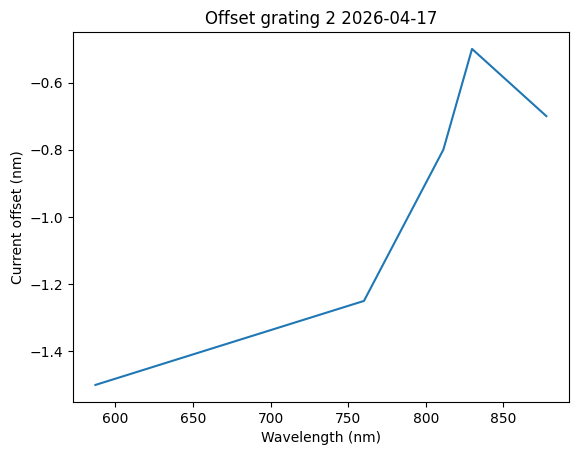

In [4]:
# grating 2 (1200 g/mm Bz 750)

# Test current calibration (2026-02-17):
# plot current calibration:
wl_current_data = np.array([
    #spectral line, current position
    [587.1,588.6],
    [760.15,761.4],
    [811.3,812.1],
    [829.8, 830.3],
    [877.7,878.4],
])
plt.figure()
plt.plot(wl_current_data[:,0], wl_current_data[:,0]- wl_current_data[:,1])
plt.title('Offset grating 2 2026-04-17')
plt.ylabel('Current offset (nm)')
plt.xlabel('Wavelength (nm)')
plt.show()

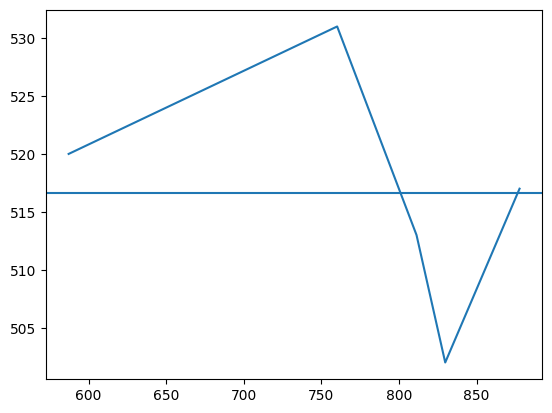

In [5]:
# grating 2 (1200 g/mm Bz 750)

# NOTE CALIBRATION INFO:
# Name: Mareny
# Calibration source: Krypton lamp, persistent lines of Hg I from 770 to 880nm.
# Spectral lines taken from: https://pml.nist.gov/PhysRefData/Handbook/Tables/kryptontable2_a.htm
# Calibration date: 2026_06_04
wl_center_data = np.array([
[587.1,520],
[760.15,531],
[811.3,513],
[829.8,502],
[877.7,517],
])
    
n0 = np.mean(wl_center_data[:,1])
n0    
plt.figure()
plt.plot(wl_center_data[:,0], wl_center_data[:,1])
plt.axhline(n0)

In [11]:
dispersion_data = np.array([
#wl_actual, wl_center, pixel
[587.1,588,520],
[587.1,563,945],
[587.1,615,60],
[760.15,760,531],
[760.15,736,982],
[760.15,785,62],
[811.3,812,513],
[811.3,788,979],
[811.3,836,46],
[829.8,831,502],
[829.8,806,995],
[829.8,855,29],
[877.7,878,517],
[877.7,855,987],
[877.7,902,26],
])


In [64]:
# MAKE SURE THE INITIAL PARAMETERS ARE GOOD !!! CHECK RESIDUAL FOR THE GOOD FITTING and adapt manually if required.
initial_guess = (300e6,0.06,0.5,0)

kwargs = dict(
    px=dispersion_data[:,2], 
    n0=np.mean(wl_center_data[:,1]),
    wl_center=dispersion_data[:,1], # nm
    m_order=1,
    d_grating=1/1200.*1e6, # nm
    x_pixel=26e3, #nm
    wl_actual=dispersion_data[:,0], # nm
    offset_adjust = 0
)
result = least_squares(fit_residual, initial_guess, kwargs=kwargs)
result.x

array([3.e+08, 6.e-02, 5.e-01, 0.e+00])

In [65]:
kwargs = dict(
    px=dispersion_data[:,2], 
    #px=wl_center_data[:,1],
    n0=np.mean(wl_center_data[:,1]),
    wl_center=dispersion_data[:,1],
    #wl_center=wl_center_data[:,0]*1e-6,
    m_order=1,
    d_grating=1/1200.*1e6, # nm
    x_pixel=26e3, #nm
    #wl_actual=dispersion_data[:,0]*1e-6,
    f = result.x[0],
    delta = result.x[1],
    gamma = result.x[2],
    offset_adjust = 0,
    curvature = result.x[3]
)

wl_p_calib_p2(**kwargs) - dispersion_data[:,0]

array([1.09908475, 0.884834  , 1.07892514, 0.61612752, 0.47745135,
       0.55921198, 0.51489323, 0.33460704, 0.38834551, 0.45904418,
       0.32071736, 0.33290858, 0.31957042, 0.16023965, 0.16168872])

In [66]:
# to store for ini file
# f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature
Y = 'f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature'.split(', ')
str([ kwargs[x] for x in Y ])
#kwargs

'[np.float64(300000000.0), np.float64(0.06), np.float64(0.5), np.float64(516.6), 0, 833.3333333333334, 26000.0, np.float64(0.0)]'

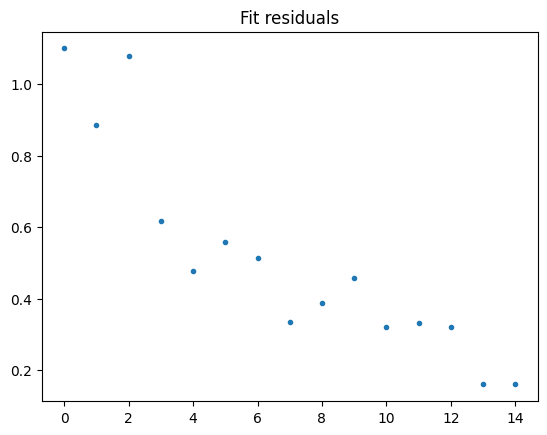

In [67]:
fig = plt.figure()
f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature = [ kwargs[x] for x in Y ]  #[np.float64(490000000.0), np.float64(1.0), np.float64(0.5), np.float64(243.0), 0, 4926.108374384236, 24000.0, np.float64(0.0)]
residual = wl_p_calib_p2(dispersion_data[:,2], n0, offset_adjust, dispersion_data[:,1], 1, d_grating, x_pixel, f, delta, gamma, curvature)-dispersion_data[:,0]

#plt.plot(wl_p_calib_p2(**kwargs))
plt.plot(residual,'.')
plt.title("Fit residuals")
plt.show()

## Grating 2(1200 g/mm Bz 500)

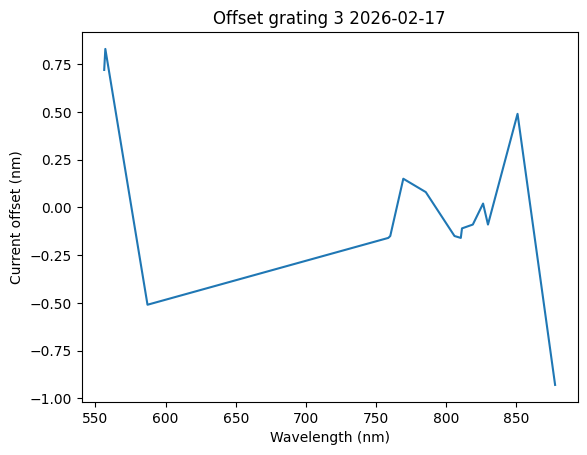

In [29]:

# grating 2 (1200 g/mm Bz 500)

# Test current calibration (2026-02-17):
# plot current calibration:
wl_current_data = np.array([
    #spectral line, current position
    [556.22, 555.5],
    [557.03, 556.2],
    [587.09, 587.6],
    [758.74, 758.9],
    [760.15, 760.3],
    [768.52, 768.4],
    [769.45, 769.3],
    [785.48, 785.4],
    [805.95, 806.1],
    [810.44, 810.6],
    [811.29, 811.4],
    [819.01, 819.1],
    [826.32, 826.3],
    [829.81, 829.9],
    [850.89, 850.4],
    [877.67, 878.6],
])
plt.figure()
plt.plot(wl_current_data[:,0], wl_current_data[:,0]- wl_current_data[:,1])
plt.ylabel('Current offset (nm)')
plt.xlabel('Wavelength (nm)')
plt.title('Offset grating 3 2026-02-17')
plt.show()

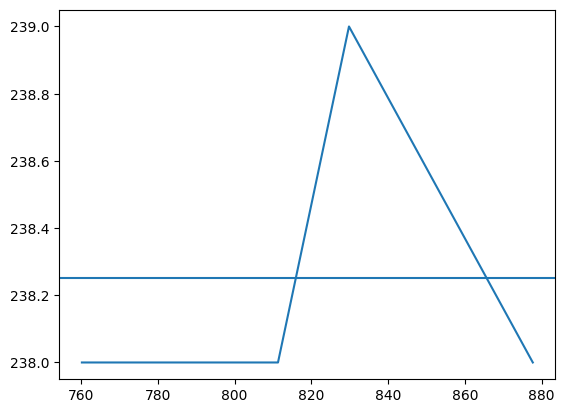

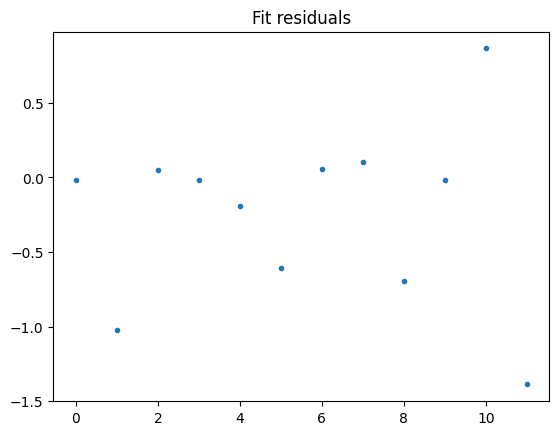

'[np.float64(1197096958.9926493), np.float64(-18.68106438263782), np.float64(-1.6871589585359328), np.float64(238.25), 0, 4926.108374384236, 24000.0, np.float64(-6.663483223202162e-06)]'

In [11]:


# NOTE CALIBRATION INFO:
# Name: David Tiede
# Calibration source: Krypton lamp, persistent lines of Hg I from 770 to 880nm.
# Spectral lines taken from: https://pml.nist.gov/PhysRefData/Handbook/Tables/kryptontable2_a.htm
# Calibration date: 2025_09_26
wl_center_data = np.array([
    [760.2, 238],
    [811.3, 238],
    [829.8, 239],
    [877.7, 238],
])

n0 = np.mean(wl_center_data[:, 1])
n0
plt.figure()
plt.plot(wl_center_data[:, 0], wl_center_data[:, 1])
plt.axhline(n0)
dispersion_data = np.array([
    #wl_actual, wl_center, pixel
    [760.2,760.2 ,238],
    [760.2,740 ,509],
    [760.2,776 ,26],
    [811.3,811.3 ,238],
    [811.3, 792,506],
    [811.3, 828,7],
    [829.8,829.8 ,239],
    [829.8,812 ,488],
    [829.8, 846,13],
    [877.7,877.7 ,238],
    [877.7, 859,510],
    [877.7, 893,17],
])

# MAKE SURE THE INITIAL PARAMETERS ARE GOOD !!! CHECK RESIDUAL FOR THE GOOD FITTING and adapt manually if required.
initial_guess = (150e6, 0.5, 0.1, 0)

kwargs = dict(
    px=dispersion_data[:, 2],
    n0=np.mean(wl_center_data[:, 1]),
    wl_center=dispersion_data[:, 1],  # nm
    m_order=1,
    d_grating=1 / 203. * 1e6,  # nm
    x_pixel=24e3,  #nm
    wl_actual=dispersion_data[:, 0],  # nm
    offset_adjust=0
)
result = least_squares(fit_residual, initial_guess, kwargs=kwargs)
result.x
kwargs = dict(
    px=dispersion_data[:, 2],
    #px=wl_center_data[:,1],
    n0=np.mean(wl_center_data[:, 1]),
    wl_center=dispersion_data[:, 1],
    #wl_center=wl_center_data[:,0]*1e-6,
    m_order=1,
    d_grating=1 / 203. * 1e6,  # nm
    x_pixel=24e3,  #nm
    #wl_actual=dispersion_data[:,0]*1e-6,
    f=result.x[0],
    delta=result.x[1],
    gamma=result.x[2],
    offset_adjust=0,
    curvature=result.x[3]
)

wl_p_calib_p2(**kwargs) - dispersion_data[:, 0]
# to store for ini file
# f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature
Y = 'f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature'.split(', ')
str([kwargs[x] for x in Y])

#kwargs
fig = plt.figure()
f, delta, gamma, n0, offset_adjust, d_grating, x_pixel, curvature = [kwargs[x] for x in
                                                                     Y]  #[np.float64(1197096958.9926493), np.float64(-18.68106438263782), np.float64(-1.6871589585359328), np.float64(238.25), 0, 4926.108374384236, 24000.0, np.float64(-6.663483223202162e-06)]
residual = wl_p_calib_p2(dispersion_data[:, 2], n0, offset_adjust, dispersion_data[:, 1], 1, d_grating, x_pixel, f,
                         delta, gamma, curvature) - dispersion_data[:, 0]

#plt.plot(wl_p_calib_p2(**kwargs))
plt.plot(residual, '.')
plt.title("Fit residuals")
plt.show()

str([kwargs[x] for x in Y])